In [6]:
import re
import matplotlib.pyplot as plt

In [7]:
# Paste your log data here as a multiline string
# log_data = """
# Ep    1/1000  timeout    Reward  -263.18  Dist  237.9px  Steps  700  eps 0.9985  Mem   700
# Ep    2/1000  GOAL       Reward  +297.73  Dist   57.8px  Steps  373  eps 0.9970  Mem  1073
# Ep    3/1000  timeout    Reward  -353.51  Dist  717.9px  Steps  700  eps 0.9955  Mem  1773
# Ep    4/1000  GOAL       Reward  +400.99  Dist   58.9px  Steps   98  eps 0.9940  Mem  1871
# Ep    5/1000  timeout    Reward  -553.64  Dist  425.7px  Steps  700  eps 0.9925  Mem  2571
# Ep    6/1000  GOAL       Reward  +234.15  Dist   59.3px  Steps  278  eps 0.9910  Mem  2849
# Ep    7/1000  timeout    Reward  -670.51  Dist  560.4px  Steps  700  eps 0.9895  Mem  3549
# Ep    8/1000  timeout    Reward  -333.95  Dist  340.7px  Steps  700  eps 0.9881  Mem  4249
# Ep    9/1000  timeout    Reward   -50.31  Dist   67.2px  Steps  700  eps 0.9866  Mem  4949
# Ep   10/1000  timeout    Reward  -359.78  Dist  546.6px  Steps  700  eps 0.9851  Mem  5649
# Ep   11/1000  timeout    Reward  -453.36  Dist  703.1px  Steps  700  eps 0.9836  Mem  6349
# Ep   12/1000  timeout    Reward  -209.97  Dist  282.6px  Steps  700  eps 0.9821  Mem  7049
# Ep   13/1000  timeout    Reward  -375.63  Dist  299.8px  Steps  700  eps 0.9807  Mem  7749
# Ep   14/1000  timeout    Reward  -273.70  Dist  684.3px  Steps  700  eps 0.9792  Mem  8449
# Ep   15/1000  GOAL       Reward  +286.75  Dist   59.7px  Steps  106  eps 0.9777  Mem  8555
# Ep   16/1000  GOAL       Reward  +284.64  Dist   59.3px  Steps  342  eps 0.9763  Mem  8897
# Ep   17/1000  timeout    Reward  -295.23  Dist  749.1px  Steps  700  eps 0.9748  Mem  9597
# Ep   18/1000  timeout    Reward  -199.38  Dist  640.7px  Steps  700  eps 0.9733  Mem 10297
# Ep   19/1000  GOAL       Reward  +327.49  Dist   58.9px  Steps  492  eps 0.9719  Mem 10789
# Ep   20/1000  timeout    Reward  -237.98  Dist  389.3px  Steps  700  eps 0.9704  Mem 11489
# Ep   21/1000  GOAL       Reward  +243.25  Dist   59.8px  Steps   48  eps 0.9690  Mem 11537
# Ep   22/1000  timeout    Reward  -175.00  Dist  419.8px  Steps  700  eps 0.9675  Mem 12237
# Ep   23/1000  GOAL       Reward  +433.87  Dist   59.3px  Steps  198  eps 0.9661  Mem 12435
# Ep   24/1000  timeout    Reward  -524.08  Dist  868.4px  Steps  700  eps 0.9646  Mem 13135
# Ep   25/1000  timeout    Reward  -347.21  Dist  376.9px  Steps  700  eps 0.9632  Mem 13835
# Ep   26/1000  timeout    Reward   -59.58  Dist  394.0px  Steps  700  eps 0.9617  Mem 14535
# Ep   27/1000  timeout    Reward  -194.39  Dist  380.1px  Steps  700  eps 0.9603  Mem 15235
# Ep   28/1000  timeout    Reward  -203.34  Dist  547.5px  Steps  700  eps 0.9588  Mem 15935
# Ep   29/1000  GOAL       Reward  +183.72  Dist   59.9px  Steps  258  eps 0.9574  Mem 16193
# Ep   30/1000  GOAL       Reward  +274.63  Dist   59.7px  Steps  538  eps 0.9560  Mem 16731
# Ep   31/1000  timeout    Reward  -433.13  Dist  718.8px  Steps  700  eps 0.9545  Mem 17431
# Ep   32/1000  GOAL       Reward  +249.60  Dist   26.8px  Steps    1  eps 0.9531  Mem 17432
# Ep   33/1000  GOAL       Reward  +357.74  Dist   59.4px  Steps  104  eps 0.9517  Mem 17536
# Ep   34/1000  GOAL       Reward  +283.02  Dist   58.6px  Steps  192  eps 0.9502  Mem 17728
# Ep   35/1000  GOAL       Reward  +390.87  Dist   58.5px  Steps  417  eps 0.9488  Mem 18145
# Ep   36/1000  GOAL       Reward  +294.21  Dist   59.9px  Steps  599  eps 0.9474  Mem 18744
# Ep   37/1000  GOAL       Reward  +117.49  Dist   58.4px  Steps  382  eps 0.9460  Mem 19126
# Ep   38/1000  GOAL       Reward  +322.23  Dist   58.9px  Steps   91  eps 0.9446  Mem 19217
# Ep   39/1000  timeout    Reward  -245.62  Dist  352.4px  Steps  700  eps 0.9431  Mem 19917
# Ep   40/1000  GOAL       Reward  +196.88  Dist   59.3px  Steps  232  eps 0.9417  Mem 20149
# Ep   41/1000  GOAL       Reward  +267.94  Dist   58.5px  Steps   48  eps 0.9403  Mem 20197
# Ep   42/1000  GOAL       Reward  +412.46  Dist   58.3px  Steps  342  eps 0.9389  Mem 20539
# Ep   43/1000  timeout    Reward   +25.44  Dist  272.7px  Steps  700  eps 0.9375  Mem 21239
# Ep   44/1000  timeout    Reward  +110.53  Dist  103.4px  Steps  700  eps 0.9361  Mem 21939
# Ep   45/1000  GOAL       Reward  +242.64  Dist   59.7px  Steps  261  eps 0.9347  Mem 22200
# Ep   46/1000  timeout    Reward  -110.35  Dist  520.8px  Steps  700  eps 0.9333  Mem 22900
# Ep   47/1000  timeout    Reward    -1.40  Dist  142.5px  Steps  700  eps 0.9319  Mem 23600
# Ep   48/1000  timeout    Reward  -555.63  Dist  628.6px  Steps  700  eps 0.9305  Mem 24300
# Ep   49/1000  timeout    Reward   -98.89  Dist  546.4px  Steps  700  eps 0.9291  Mem 25000
# Ep   50/1000  GOAL       Reward  +385.59  Dist   59.5px  Steps  223  eps 0.9277  Mem 25223
# Ep   51/1000  GOAL       Reward  +249.60  Dist   25.8px  Steps    1  eps 0.9263  Mem 25224
# Ep   52/1000  timeout    Reward   +92.79  Dist  212.9px  Steps  700  eps 0.9249  Mem 25924
# Ep   53/1000  timeout    Reward  -110.33  Dist  482.1px  Steps  700  eps 0.9235  Mem 26624
# Ep   54/1000  GOAL       Reward  +280.16  Dist   59.3px  Steps   56  eps 0.9221  Mem 26680
# Ep   55/1000  GOAL       Reward  +497.85  Dist   58.4px  Steps  561  eps 0.9208  Mem 27241
# Ep   56/1000  timeout    Reward  +374.11  Dist  171.1px  Steps  700  eps 0.9194  Mem 27941
# Ep   57/1000  GOAL       Reward  +406.33  Dist   59.9px  Steps  375  eps 0.9180  Mem 28316
# Ep   58/1000  GOAL       Reward  +429.42  Dist   58.8px  Steps  306  eps 0.9166  Mem 28622
# Ep   59/1000  GOAL       Reward  +420.58  Dist   59.8px  Steps  299  eps 0.9152  Mem 28921
# Ep   60/1000  GOAL       Reward  +468.38  Dist   57.6px  Steps  267  eps 0.9139  Mem 29188
# Ep   61/1000  timeout    Reward  -117.97  Dist   73.6px  Steps  700  eps 0.9125  Mem 29888
# Ep   62/1000  GOAL       Reward  +249.60  Dist   34.2px  Steps    1  eps 0.9111  Mem 29889
# Ep   63/1000  GOAL       Reward  +227.34  Dist   59.7px  Steps  209  eps 0.9098  Mem 30000
# Ep   64/1000  GOAL       Reward  +213.42  Dist   59.6px  Steps  436  eps 0.9084  Mem 30000
# Ep   65/1000  timeout    Reward  -175.95  Dist  169.7px  Steps  700  eps 0.9070  Mem 30000
# Ep   66/1000  GOAL       Reward  +535.26  Dist   59.2px  Steps  532  eps 0.9057  Mem 30000
# Ep   67/1000  GOAL       Reward  +249.60  Dist   29.1px  Steps    1  eps 0.9043  Mem 30000
# Ep   68/1000  GOAL       Reward  +677.30  Dist   58.3px  Steps  345  eps 0.9030  Mem 30000
# Ep   69/1000  GOAL       Reward  +132.85  Dist   58.6px  Steps  203  eps 0.9016  Mem 30000
# Ep   70/1000  timeout    Reward  -345.29  Dist  188.9px  Steps  700  eps 0.9003  Mem 30000
# Ep   71/1000  timeout    Reward  -186.33  Dist  206.0px  Steps  700  eps 0.8989  Mem 30000
# Ep   72/1000  GOAL       Reward  +247.03  Dist   59.1px  Steps   42  eps 0.8976  Mem 30000
# Ep   73/1000  GOAL       Reward  +321.97  Dist   57.6px  Steps  101  eps 0.8962  Mem 30000
# Ep   74/1000  GOAL       Reward  +141.54  Dist   58.3px  Steps  157  eps 0.8949  Mem 30000
# Ep   75/1000  GOAL       Reward  +134.03  Dist   59.9px  Steps  673  eps 0.8935  Mem 30000
# Ep   76/1000  GOAL       Reward  +244.82  Dist   58.8px  Steps   11  eps 0.8922  Mem 30000
# Ep   77/1000  GOAL       Reward  +254.20  Dist   58.2px  Steps   17  eps 0.8908  Mem 30000
# Ep   78/1000  GOAL       Reward  +327.92  Dist   59.4px  Steps  382  eps 0.8895  Mem 30000
# Ep   79/1000  GOAL       Reward  +273.16  Dist   58.2px  Steps   54  eps 0.8882  Mem 30000
# Ep   80/1000  GOAL       Reward  +249.60  Dist   32.3px  Steps    1  eps 0.8868  Mem 30000
# Ep   81/1000  GOAL       Reward  +249.60  Dist   48.8px  Steps    1  eps 0.8855  Mem 30000
# Ep   82/1000  GOAL       Reward  +294.58  Dist   59.9px  Steps  126  eps 0.8842  Mem 30000
# Ep   83/1000  GOAL       Reward  +197.39  Dist   58.5px  Steps  669  eps 0.8829  Mem 30000
# Ep   84/1000  GOAL       Reward  +249.60  Dist   17.6px  Steps    1  eps 0.8815  Mem 30000
# Ep   85/1000  timeout    Reward  -547.64  Dist  948.4px  Steps  700  eps 0.8802  Mem 30000
# Ep   86/1000  GOAL       Reward  +237.63  Dist   60.0px  Steps  116  eps 0.8789  Mem 30000
# Ep   87/1000  GOAL       Reward  +725.02  Dist   57.7px  Steps  357  eps 0.8776  Mem 30000
# Ep   88/1000  GOAL       Reward  +310.36  Dist   59.6px  Steps  420  eps 0.8763  Mem 30000
# Ep   89/1000  timeout    Reward  -690.01  Dist  705.1px  Steps  700  eps 0.8749  Mem 30000
# Ep   90/1000  GOAL       Reward  +481.04  Dist   58.8px  Steps  388  eps 0.8736  Mem 30000
# Ep   91/1000  GOAL       Reward  +249.60  Dist   29.4px  Steps    1  eps 0.8723  Mem 30000
# Ep   92/1000  GOAL       Reward  +249.60  Dist   14.1px  Steps    1  eps 0.8710  Mem 30000
# Ep   93/1000  GOAL       Reward  +249.60  Dist   39.3px  Steps    1  eps 0.8697  Mem 30000
# Ep   94/1000  timeout    Reward  -465.44  Dist  594.3px  Steps  700  eps 0.8684  Mem 30000
# Ep   95/1000  timeout    Reward  -379.63  Dist  265.3px  Steps  700  eps 0.8671  Mem 30000
# Ep   96/1000  timeout    Reward  -585.32  Dist  540.4px  Steps  700  eps 0.8658  Mem 30000
# Ep   97/1000  GOAL       Reward  +186.09  Dist   58.9px  Steps  268  eps 0.8645  Mem 30000
# Ep   98/1000  timeout    Reward  -485.86  Dist  705.8px  Steps  700  eps 0.8632  Mem 30000
# Ep   99/1000  timeout    Reward  -593.28  Dist  545.7px  Steps  700  eps 0.8619  Mem 30000
# Ep  100/1000  timeout    Reward  -432.18  Dist  727.8px  Steps  700  eps 0.8606  Mem 30000
# Ep  101/1000  timeout    Reward  -687.59  Dist  847.4px  Steps  700  eps 0.8593  Mem 30000
# Ep  102/1000  timeout    Reward  -651.29  Dist  614.7px  Steps  700  eps 0.8580  Mem 30000
# Ep  103/1000  timeout    Reward  -494.34  Dist  242.2px  Steps  700  eps 0.8567  Mem 30000
# Ep  104/1000  GOAL       Reward  +311.87  Dist   60.0px  Steps   87  eps 0.8555  Mem 30000
# Ep  105/1000  GOAL       Reward  +275.94  Dist   59.8px  Steps   34  eps 0.8542  Mem 30000
# Ep  106/1000  GOAL       Reward  +249.60  Dist   28.5px  Steps    1  eps 0.8529  Mem 30000
# Ep  107/1000  GOAL       Reward  +249.60  Dist   29.8px  Steps    1  eps 0.8516  Mem 30000
# Ep  108/1000  GOAL       Reward  +249.60  Dist   30.3px  Steps    1  eps 0.8503  Mem 30000
# Ep  109/1000  timeout    Reward  -787.87  Dist  634.6px  Steps  700  eps 0.8491  Mem 30000
# Ep  110/1000  GOAL       Reward  +360.22  Dist   59.9px  Steps  589  eps 0.8478  Mem 30000
# Ep  111/1000  GOAL       Reward  +242.86  Dist   59.6px  Steps  180  eps 0.8465  Mem 30000
# Ep  112/1000  GOAL       Reward  +498.49  Dist   59.5px  Steps  695  eps 0.8452  Mem 30000
# Ep  113/1000  timeout    Reward  -553.59  Dist  443.1px  Steps  700  eps 0.8440  Mem 30000
# Ep  114/1000  GOAL       Reward  +243.27  Dist   58.9px  Steps   16  eps 0.8427  Mem 30000
# Ep  115/1000  timeout    Reward  -261.42  Dist  513.4px  Steps  700  eps 0.8414  Mem 30000
# Ep  116/1000  GOAL       Reward  +249.60  Dist   34.7px  Steps    1  eps 0.8402  Mem 30000
# Ep  117/1000  GOAL       Reward  +451.05  Dist   58.0px  Steps  391  eps 0.8389  Mem 30000
# Ep  118/1000  timeout    Reward  -467.98  Dist  698.3px  Steps  700  eps 0.8377  Mem 30000
# Ep  119/1000  GOAL       Reward  +380.46  Dist   58.8px  Steps  234  eps 0.8364  Mem 30000
# Ep  120/1000  timeout    Reward  -237.34  Dist  232.5px  Steps  700  eps 0.8352  Mem 30000
# Ep  121/1000  timeout    Reward  -264.35  Dist  225.1px  Steps  700  eps 0.8339  Mem 30000
# Ep  122/1000  timeout    Reward  -482.03  Dist  470.5px  Steps  700  eps 0.8327  Mem 30000
# Ep  123/1000  GOAL       Reward  +430.28  Dist   56.9px  Steps  201  eps 0.8314  Mem 30000
# Ep  124/1000  GOAL       Reward  +607.58  Dist   59.6px  Steps  694  eps 0.8302  Mem 30000
# Ep  125/1000  GOAL       Reward  +421.84  Dist   57.9px  Steps  236  eps 0.8289  Mem 30000
# Ep  126/1000  timeout    Reward  +154.39  Dist  157.6px  Steps  700  eps 0.8277  Mem 30000
# Ep  127/1000  timeout    Reward  -215.38  Dist  217.2px  Steps  700  eps 0.8264  Mem 30000
# Ep  128/1000  GOAL       Reward  +239.63  Dist   59.1px  Steps   90  eps 0.8252  Mem 30000
# Ep  129/1000  GOAL       Reward  +287.25  Dist   59.8px  Steps   53  eps 0.8240  Mem 30000
# Ep  130/1000  timeout    Reward   -85.61  Dist  363.6px  Steps  700  eps 0.8227  Mem 30000
# Ep  131/1000  GOAL       Reward  +256.28  Dist   59.9px  Steps  302  eps 0.8215  Mem 30000
# Ep  132/1000  GOAL       Reward  +334.10  Dist   59.3px  Steps  176  eps 0.8202  Mem 30000
# Ep  133/1000  GOAL       Reward  +504.16  Dist   59.1px  Steps  404  eps 0.8190  Mem 30000
# Ep  134/1000  GOAL       Reward  +249.60  Dist   16.5px  Steps    1  eps 0.8178  Mem 30000
# Ep  135/1000  GOAL       Reward  +264.83  Dist   59.3px  Steps   99  eps 0.8166  Mem 30000
# Ep  136/1000  GOAL       Reward  +405.05  Dist   59.6px  Steps  104  eps 0.8153  Mem 30000
# Ep  137/1000  timeout    Reward   -57.65  Dist  350.7px  Steps  700  eps 0.8141  Mem 30000
# Ep  138/1000  timeout    Reward  +247.63  Dist  437.2px  Steps  700  eps 0.8129  Mem 30000
# Ep  139/1000  timeout    Reward  -162.97  Dist  117.9px  Steps  700  eps 0.8117  Mem 30000
# Ep  140/1000  GOAL       Reward  +562.38  Dist   59.8px  Steps  393  eps 0.8105  Mem 30000
# Ep  141/1000  GOAL       Reward  +725.90  Dist   58.5px  Steps  284  eps 0.8092  Mem 30000
# Ep  142/1000  timeout    Reward  +100.92  Dist  204.0px  Steps  700  eps 0.8080  Mem 30000
# Ep  143/1000  timeout    Reward  -400.23  Dist  529.7px  Steps  700  eps 0.8068  Mem 30000
# Ep  144/1000  timeout    Reward  -308.42  Dist  431.4px  Steps  700  eps 0.8056  Mem 30000
# Ep  145/1000  GOAL       Reward  +526.37  Dist   58.4px  Steps  195  eps 0.8044  Mem 30000
# Ep  146/1000  GOAL       Reward  +207.80  Dist   59.9px  Steps  115  eps 0.8032  Mem 30000
# Ep  147/1000  GOAL       Reward  +231.33  Dist   60.0px  Steps   73  eps 0.8020  Mem 30000
# Ep  148/1000  GOAL       Reward  +641.74  Dist   59.7px  Steps  380  eps 0.8008  Mem 30000
# Ep  149/1000  timeout    Reward  -291.77  Dist  108.6px  Steps  700  eps 0.7996  Mem 30000
# Ep  150/1000  GOAL       Reward  +326.40  Dist   58.3px  Steps  486  eps 0.7984  Mem 30000
# Ep  151/1000  GOAL       Reward  +547.28  Dist   59.2px  Steps  235  eps 0.7972  Mem 30000
# Ep  152/1000  GOAL       Reward  +444.16  Dist   59.5px  Steps  163  eps 0.7960  Mem 30000
# Ep  153/1000  GOAL       Reward  +110.87  Dist   59.7px  Steps  179  eps 0.7948  Mem 30000
# Ep  154/1000  GOAL       Reward  +224.73  Dist   59.8px  Steps  199  eps 0.7936  Mem 30000
# Ep  155/1000  GOAL       Reward  +408.96  Dist   57.8px  Steps  125  eps 0.7924  Mem 30000
# Ep  156/1000  timeout    Reward   -72.05  Dist  306.4px  Steps  700  eps 0.7912  Mem 30000
# Ep  157/1000  GOAL       Reward  +314.80  Dist   58.2px  Steps  338  eps 0.7900  Mem 30000
# Ep  158/1000  GOAL       Reward  +253.99  Dist   59.1px  Steps  127  eps 0.7889  Mem 30000
# Ep  159/1000  GOAL       Reward  +249.60  Dist   35.8px  Steps    1  eps 0.7877  Mem 30000
# Ep  160/1000  GOAL       Reward  +321.94  Dist   59.7px  Steps  324  eps 0.7865  Mem 30000
# Ep  161/1000  GOAL       Reward  +174.85  Dist   59.4px  Steps   39  eps 0.7853  Mem 30000
# Ep  162/1000  GOAL       Reward  +471.57  Dist   59.8px  Steps  163  eps 0.7841  Mem 30000
# Ep  163/1000  GOAL       Reward  +250.35  Dist   59.7px  Steps   27  eps 0.7830  Mem 30000
# Ep  164/1000  GOAL       Reward  +128.39  Dist   58.6px  Steps  160  eps 0.7818  Mem 30000
# Ep  165/1000  GOAL       Reward  +800.06  Dist   58.5px  Steps  335  eps 0.7806  Mem 30000
# Ep  166/1000  GOAL       Reward  +247.71  Dist   59.6px  Steps   23  eps 0.7794  Mem 30000
# Ep  167/1000  timeout    Reward  -370.09  Dist  382.7px  Steps  700  eps 0.7783  Mem 30000
# Ep  168/1000  GOAL       Reward  +529.27  Dist   59.7px  Steps  180  eps 0.7771  Mem 30000
# Ep  169/1000  GOAL       Reward  +440.88  Dist   58.1px  Steps   94  eps 0.7759  Mem 30000
# Ep  170/1000  GOAL       Reward  +448.75  Dist   56.1px  Steps  132  eps 0.7748  Mem 30000
# Ep  171/1000  GOAL       Reward   +28.18  Dist   59.1px  Steps  692  eps 0.7736  Mem 30000
# Ep  172/1000  GOAL       Reward  +300.10  Dist   59.2px  Steps   58  eps 0.7724  Mem 30000
# Ep  173/1000  GOAL       Reward  +243.49  Dist   59.3px  Steps  590  eps 0.7713  Mem 30000
# Ep  174/1000  GOAL       Reward  +249.60  Dist   35.0px  Steps    1  eps 0.7701  Mem 30000
# Ep  175/1000  GOAL       Reward  +775.32  Dist   59.1px  Steps  682  eps 0.7690  Mem 30000
# Ep  176/1000  GOAL       Reward  +249.60  Dist   59.4px  Steps    1  eps 0.7678  Mem 30000
# Ep  177/1000  GOAL       Reward  +270.86  Dist   58.0px  Steps  112  eps 0.7667  Mem 30000
# Ep  178/1000  GOAL       Reward  +213.16  Dist   59.8px  Steps  436  eps 0.7655  Mem 30000
# Ep  179/1000  GOAL       Reward  +249.60  Dist   46.1px  Steps    1  eps 0.7644  Mem 30000
# Ep  180/1000  GOAL       Reward  +393.12  Dist   59.3px  Steps  152  eps 0.7632  Mem 30000
# Ep  181/1000  timeout    Reward  +137.45  Dist  250.4px  Steps  700  eps 0.7621  Mem 30000
# Ep  182/1000  GOAL       Reward   +34.63  Dist   57.8px  Steps  233  eps 0.7609  Mem 30000
# Ep  183/1000  GOAL       Reward  +377.61  Dist   58.7px  Steps  183  eps 0.7598  Mem 30000
# Ep  184/1000  GOAL       Reward  +273.17  Dist   56.8px  Steps  294  eps 0.7587  Mem 30000
# Ep  185/1000  GOAL       Reward  +276.80  Dist   58.9px  Steps   47  eps 0.7575  Mem 30000
# Ep  186/1000  GOAL       Reward  +379.33  Dist   57.9px  Steps  197  eps 0.7564  Mem 30000
# Ep  187/1000  timeout    Reward   -66.77  Dist  553.1px  Steps  700  eps 0.7552  Mem 30000
# Ep  188/1000  GOAL       Reward  +526.94  Dist   58.5px  Steps  125  eps 0.7541  Mem 30000
# Ep  189/1000  GOAL       Reward  +817.44  Dist   58.0px  Steps  182  eps 0.7530  Mem 30000
# Ep  190/1000  GOAL       Reward  +296.27  Dist   57.8px  Steps  203  eps 0.7519  Mem 30000
# Ep  191/1000  GOAL       Reward  +505.48  Dist   58.0px  Steps  155  eps 0.7507  Mem 30000
# Ep  192/1000  GOAL       Reward  +368.83  Dist   59.3px  Steps   79  eps 0.7496  Mem 30000
# Ep  193/1000  GOAL       Reward  +488.53  Dist   58.9px  Steps  103  eps 0.7485  Mem 30000
# Ep  194/1000  GOAL       Reward  +260.36  Dist   58.8px  Steps   15  eps 0.7474  Mem 30000
# Ep  195/1000  GOAL       Reward  +610.91  Dist   57.4px  Steps  146  eps 0.7462  Mem 30000
# Ep  196/1000  GOAL       Reward  +300.52  Dist   56.3px  Steps   92  eps 0.7451  Mem 30000
# Ep  197/1000  GOAL       Reward  +249.60  Dist   41.5px  Steps    1  eps 0.7440  Mem 30000
# Ep  198/1000  GOAL       Reward  +307.29  Dist   59.8px  Steps   85  eps 0.7429  Mem 30000
# Ep  199/1000  GOAL       Reward  +765.33  Dist   59.2px  Steps  603  eps 0.7418  Mem 30000
# Ep  200/1000  GOAL       Reward  +249.60  Dist   56.1px  Steps    1  eps 0.7407  Mem 30000
# Ep  201/1000  GOAL       Reward  +298.76  Dist   60.0px  Steps  197  eps 0.7395  Mem 30000
# Ep  202/1000  timeout    Reward    -8.35  Dist  193.2px  Steps  700  eps 0.7384  Mem 30000
# Ep  203/1000  GOAL       Reward  +504.98  Dist   59.2px  Steps   78  eps 0.7373  Mem 30000
# Ep  204/1000  GOAL       Reward  +237.58  Dist   59.8px  Steps   91  eps 0.7362  Mem 30000
# Ep  205/1000  GOAL       Reward  +775.91  Dist   59.2px  Steps  319  eps 0.7351  Mem 30000
# Ep  206/1000  GOAL       Reward  +249.60  Dist   12.8px  Steps    1  eps 0.7340  Mem 30000
# Ep  207/1000  GOAL       Reward  +748.35  Dist   59.6px  Steps  276  eps 0.7329  Mem 30000
# Ep  208/1000  GOAL       Reward  +777.13  Dist   58.0px  Steps  226  eps 0.7318  Mem 30000
# Ep  209/1000  timeout    Reward  -290.29  Dist  206.3px  Steps  700  eps 0.7307  Mem 30000
# Ep  210/1000  GOAL       Reward  +291.69  Dist   58.4px  Steps   58  eps 0.7296  Mem 30000
# Ep  211/1000  GOAL       Reward  +413.56  Dist   58.6px  Steps   67  eps 0.7285  Mem 30000
# Ep  212/1000  GOAL       Reward  +827.25  Dist   58.8px  Steps  287  eps 0.7274  Mem 30000
# Ep  213/1000  GOAL       Reward  +249.60  Dist   57.4px  Steps    1  eps 0.7263  Mem 30000
# Ep  214/1000  timeout    Reward   +37.86  Dist  220.3px  Steps  700  eps 0.7252  Mem 30000
# Ep  215/1000  GOAL       Reward  +309.45  Dist   57.3px  Steps   36  eps 0.7242  Mem 30000
# Ep  216/1000  GOAL       Reward  +550.15  Dist   58.3px  Steps  217  eps 0.7231  Mem 30000
# Ep  217/1000  timeout    Reward   -52.47  Dist  309.8px  Steps  700  eps 0.7220  Mem 30000
# Ep  218/1000  GOAL       Reward  +417.86  Dist   59.1px  Steps  105  eps 0.7209  Mem 30000
# Ep  219/1000  GOAL       Reward  +599.00  Dist   59.3px  Steps  127  eps 0.7198  Mem 30000
# Ep  220/1000  GOAL       Reward   +55.11  Dist   59.4px  Steps  492  eps 0.7187  Mem 30000
# Ep  221/1000  GOAL       Reward  +607.31  Dist   58.6px  Steps  149  eps 0.7177  Mem 30000
# Ep  222/1000  GOAL       Reward  +252.38  Dist   59.2px  Steps    8  eps 0.7166  Mem 30000
# Ep  223/1000  timeout    Reward  -346.10  Dist  389.8px  Steps  700  eps 0.7155  Mem 30000
# Ep  224/1000  GOAL       Reward  +494.74  Dist   59.3px  Steps  125  eps 0.7144  Mem 30000
# Ep  225/1000  GOAL       Reward  +475.11  Dist   57.8px  Steps  144  eps 0.7134  Mem 30000
# Ep  226/1000  GOAL       Reward  +674.38  Dist   57.7px  Steps  192  eps 0.7123  Mem 30000
# Ep  227/1000  GOAL       Reward  +425.52  Dist   57.5px  Steps  181  eps 0.7112  Mem 30000
# Ep  228/1000  GOAL       Reward  +648.68  Dist   59.5px  Steps  292  eps 0.7102  Mem 30000
# Ep  229/1000  GOAL       Reward  +546.44  Dist   59.7px  Steps  230  eps 0.7091  Mem 30000
# Ep  230/1000  GOAL       Reward  +511.34  Dist   58.2px  Steps   93  eps 0.7080  Mem 30000
# Ep  231/1000  GOAL       Reward  +548.97  Dist   59.6px  Steps  350  eps 0.7070  Mem 30000
# Ep  232/1000  GOAL       Reward  +457.67  Dist   59.7px  Steps   63  eps 0.7059  Mem 30000
# Ep  233/1000  GOAL       Reward  +241.88  Dist   59.5px  Steps   92  eps 0.7049  Mem 30000
# Ep  234/1000  GOAL       Reward  +263.85  Dist   57.4px  Steps  214  eps 0.7038  Mem 30000
# Ep  235/1000  GOAL       Reward  +623.78  Dist   59.2px  Steps  222  eps 0.7027  Mem 30000
# Ep  236/1000  GOAL       Reward  +239.36  Dist   58.0px  Steps   89  eps 0.7017  Mem 30000
# Ep  237/1000  GOAL       Reward  +173.72  Dist   58.8px  Steps   66  eps 0.7006  Mem 30000
# Ep  238/1000  GOAL       Reward  +479.93  Dist   58.0px  Steps  161  eps 0.6996  Mem 30000
# Ep  239/1000  GOAL       Reward  +624.98  Dist   56.0px  Steps  136  eps 0.6985  Mem 30000
# Ep  240/1000  GOAL       Reward  +249.60  Dist   52.0px  Steps    1  eps 0.6975  Mem 30000
# Ep  241/1000  GOAL       Reward  +786.42  Dist   58.9px  Steps  332  eps 0.6964  Mem 30000
# Ep  242/1000  GOAL       Reward  +458.99  Dist   57.5px  Steps  133  eps 0.6954  Mem 30000
# Ep  243/1000  GOAL       Reward  +442.55  Dist   59.6px  Steps  313  eps 0.6944  Mem 30000
# Ep  244/1000  GOAL       Reward  +245.67  Dist   59.9px  Steps    6  eps 0.6933  Mem 30000
# Ep  245/1000  GOAL       Reward  +254.55  Dist   58.6px  Steps   24  eps 0.6923  Mem 30000
# Ep  246/1000  GOAL       Reward  +801.20  Dist   57.2px  Steps  280  eps 0.6912  Mem 30000
# Ep  247/1000  GOAL       Reward  +764.00  Dist   59.2px  Steps  257  eps 0.6902  Mem 30000
# Ep  248/1000  GOAL       Reward  +107.89  Dist   60.0px  Steps  171  eps 0.6892  Mem 30000
# Ep  249/1000  GOAL       Reward  +566.76  Dist   59.0px  Steps  125  eps 0.6881  Mem 30000
# Ep  250/1000  GOAL       Reward  +218.90  Dist   59.9px  Steps  112  eps 0.6871  Mem 30000
# Ep  251/1000  GOAL       Reward  +314.06  Dist   58.5px  Steps   34  eps 0.6861  Mem 30000
# Ep  252/1000  GOAL       Reward  +249.60  Dist   36.6px  Steps    1  eps 0.6850  Mem 30000
# Ep  253/1000  timeout    Reward  +151.79  Dist  108.7px  Steps  700  eps 0.6840  Mem 30000
# Ep  254/1000  GOAL       Reward  +540.71  Dist   58.8px  Steps  123  eps 0.6830  Mem 30000
# Ep  255/1000  GOAL       Reward  +660.26  Dist   58.7px  Steps  221  eps 0.6820  Mem 30000
# Ep  256/1000  GOAL       Reward  +239.74  Dist   59.0px  Steps   88  eps 0.6809  Mem 30000
# Ep  257/1000  GOAL       Reward  +634.40  Dist   59.1px  Steps  178  eps 0.6799  Mem 30000
# Ep  258/1000  GOAL       Reward  +625.19  Dist   57.7px  Steps  150  eps 0.6789  Mem 30000
# Ep  259/1000  GOAL       Reward  +385.14  Dist   58.9px  Steps  239  eps 0.6779  Mem 30000
# Ep  260/1000  GOAL       Reward  +643.09  Dist   59.5px  Steps  127  eps 0.6769  Mem 30000
# Ep  261/1000  timeout    Reward  +151.48  Dist   86.1px  Steps  700  eps 0.6758  Mem 30000
# Ep  262/1000  GOAL       Reward  +249.60  Dist   39.3px  Steps    1  eps 0.6748  Mem 30000
# Ep  263/1000  GOAL       Reward  +268.69  Dist   57.9px  Steps   45  eps 0.6738  Mem 30000
# Ep  264/1000  GOAL       Reward  +338.90  Dist   58.9px  Steps  133  eps 0.6728  Mem 30000
# Ep  265/1000  GOAL       Reward  +207.06  Dist   59.7px  Steps  491  eps 0.6718  Mem 30000
# Ep  266/1000  GOAL       Reward   +82.90  Dist   56.2px  Steps  219  eps 0.6708  Mem 30000
# Ep  267/1000  GOAL       Reward  +250.10  Dist   58.8px  Steps   82  eps 0.6698  Mem 30000
# Ep  268/1000  timeout    Reward  +128.50  Dist  162.6px  Steps  700  eps 0.6688  Mem 30000
# Ep  269/1000  GOAL       Reward  +348.20  Dist   59.2px  Steps   68  eps 0.6678  Mem 30000
# Ep  270/1000  timeout    Reward  -261.22  Dist  100.1px  Steps  700  eps 0.6668  Mem 30000
# Ep  271/1000  timeout    Reward  -325.67  Dist  147.3px  Steps  700  eps 0.6658  Mem 30000
# Ep  272/1000  GOAL       Reward  +249.60  Dist   56.5px  Steps    1  eps 0.6648  Mem 30000
# Ep  273/1000  GOAL       Reward  +384.25  Dist   58.5px  Steps   97  eps 0.6638  Mem 30000
# Ep  274/1000  GOAL       Reward  +459.09  Dist   59.9px  Steps  180  eps 0.6628  Mem 30000
# Ep  275/1000  timeout    Reward  -179.99  Dist  122.7px  Steps  700  eps 0.6618  Mem 30000
# Ep  276/1000  GOAL       Reward  +354.52  Dist   59.9px  Steps  144  eps 0.6608  Mem 30000
# Ep  277/1000  timeout    Reward  -427.12  Dist  220.3px  Steps  700  eps 0.6598  Mem 30000
# Ep  278/1000  GOAL       Reward  +272.01  Dist   59.4px  Steps   23  eps 0.6588  Mem 30000
# Ep  279/1000  GOAL       Reward  +379.53  Dist   58.2px  Steps   85  eps 0.6578  Mem 30000
# Ep  280/1000  GOAL       Reward  +675.75  Dist   59.6px  Steps  175  eps 0.6568  Mem 30000
# Ep  281/1000  GOAL       Reward  +434.39  Dist   59.6px  Steps  250  eps 0.6559  Mem 30000
# Ep  282/1000  timeout    Reward  -217.52  Dist  263.3px  Steps  700  eps 0.6549  Mem 30000
# Ep  283/1000  timeout    Reward  -177.53  Dist   92.5px  Steps  700  eps 0.6539  Mem 30000
# Ep  284/1000  GOAL       Reward  +591.74  Dist   59.4px  Steps  435  eps 0.6529  Mem 30000
# Ep  285/1000  timeout    Reward   -83.79  Dist  267.7px  Steps  700  eps 0.6519  Mem 30000
# Ep  286/1000  GOAL       Reward  +360.85  Dist   58.9px  Steps   84  eps 0.6510  Mem 30000
# Ep  287/1000  GOAL       Reward  +620.67  Dist   59.6px  Steps  161  eps 0.6500  Mem 30000
# Ep  288/1000  GOAL       Reward  +612.69  Dist   58.5px  Steps  164  eps 0.6490  Mem 30000
# Ep  289/1000  GOAL       Reward  +522.28  Dist   59.7px  Steps  445  eps 0.6480  Mem 30000
# Ep  290/1000  timeout    Reward  -233.46  Dist  113.7px  Steps  700  eps 0.6471  Mem 30000
# Ep  291/1000  GOAL       Reward  +526.20  Dist   57.5px  Steps  100  eps 0.6461  Mem 30000
# Ep  292/1000  GOAL       Reward  +704.51  Dist   59.2px  Steps  207  eps 0.6451  Mem 30000
# Ep  293/1000  GOAL       Reward  +395.72  Dist   58.6px  Steps  425  eps 0.6441  Mem 30000
# Ep  294/1000  timeout    Reward  +200.21  Dist  197.3px  Steps  700  eps 0.6432  Mem 30000
# Ep  295/1000  GOAL       Reward  +630.41  Dist   59.9px  Steps  177  eps 0.6422  Mem 30000
# Ep  296/1000  timeout    Reward  -122.73  Dist  155.9px  Steps  700  eps 0.6413  Mem 30000
# Ep  297/1000  GOAL       Reward  +304.12  Dist   56.5px  Steps   21  eps 0.6403  Mem 30000
# Ep  298/1000  GOAL       Reward  +356.16  Dist   56.5px  Steps   36  eps 0.6393  Mem 30000
# Ep  299/1000  GOAL       Reward  +265.67  Dist   59.8px  Steps   26  eps 0.6384  Mem 30000
# Ep  300/1000  GOAL       Reward  +367.14  Dist   55.5px  Steps   81  eps 0.6374  Mem 30000
# Ep  301/1000  GOAL       Reward  +339.29  Dist   58.3px  Steps   38  eps 0.6365  Mem 30000
# Ep  302/1000  GOAL       Reward  +465.71  Dist   59.9px  Steps  210  eps 0.6355  Mem 30000
# Ep  303/1000  GOAL       Reward  +303.39  Dist   58.6px  Steps   78  eps 0.6345  Mem 30000
# Ep  304/1000  GOAL       Reward  +492.57  Dist   55.4px  Steps   74  eps 0.6336  Mem 30000
# Ep  305/1000  timeout    Reward   -55.23  Dist  241.2px  Steps  700  eps 0.6326  Mem 30000
# Ep  306/1000  GOAL       Reward  +173.48  Dist   59.5px  Steps   85  eps 0.6317  Mem 30000
# Ep  307/1000  GOAL       Reward  +312.53  Dist   57.6px  Steps  189  eps 0.6307  Mem 30000
# Ep  308/1000  GOAL       Reward  +345.47  Dist   57.1px  Steps   46  eps 0.6298  Mem 30000
# Ep  309/1000  GOAL       Reward  +363.48  Dist   59.9px  Steps  142  eps 0.6289  Mem 30000
# Ep  310/1000  GOAL       Reward   +23.64  Dist   59.2px  Steps  675  eps 0.6279  Mem 30000
# Ep  311/1000  timeout    Reward  +492.96  Dist  173.9px  Steps  700  eps 0.6270  Mem 30000
# Ep  312/1000  GOAL       Reward  +515.01  Dist   59.3px  Steps   96  eps 0.6260  Mem 30000
# Ep  313/1000  GOAL       Reward  +516.37  Dist   59.1px  Steps  113  eps 0.6251  Mem 30000
# Ep  314/1000  GOAL       Reward  +412.99  Dist   60.0px  Steps   49  eps 0.6242  Mem 30000
# Ep  315/1000  timeout    Reward  +236.05  Dist  196.2px  Steps  700  eps 0.6232  Mem 30000
# Ep  316/1000  timeout    Reward  -106.00  Dist  163.5px  Steps  700  eps 0.6223  Mem 30000
# Ep  317/1000  GOAL       Reward  +657.16  Dist   59.8px  Steps   97  eps 0.6214  Mem 30000
# Ep  318/1000  GOAL       Reward  +745.54  Dist   59.7px  Steps  607  eps 0.6204  Mem 30000
# Ep  319/1000  GOAL       Reward  +249.60  Dist   37.2px  Steps    1  eps 0.6195  Mem 30000
# Ep  320/1000  GOAL       Reward  +895.08  Dist   60.0px  Steps  226  eps 0.6186  Mem 30000
# Ep  321/1000  GOAL       Reward  +249.60  Dist   40.0px  Steps    1  eps 0.6176  Mem 30000
# Ep  322/1000  GOAL       Reward  +186.88  Dist   57.7px  Steps  200  eps 0.6167  Mem 30000
# Ep  323/1000  GOAL       Reward  +411.87  Dist   57.7px  Steps  269  eps 0.6158  Mem 30000
# Ep  324/1000  GOAL       Reward  +839.33  Dist   59.2px  Steps  276  eps 0.6149  Mem 30000
# Ep  325/1000  timeout    Reward  +439.46  Dist  192.2px  Steps  700  eps 0.6139  Mem 30000
# Ep  326/1000  GOAL       Reward  +359.20  Dist   58.7px  Steps   49  eps 0.6130  Mem 30000
# Ep  327/1000  GOAL       Reward  +484.61  Dist   57.6px  Steps  173  eps 0.6121  Mem 30000
# Ep  328/1000  timeout    Reward  +533.02  Dist  125.4px  Steps  700  eps 0.6112  Mem 30000
# Ep  329/1000  GOAL       Reward  +249.60  Dist   13.4px  Steps    1  eps 0.6103  Mem 30000
# Ep  330/1000  GOAL       Reward  +346.23  Dist   59.1px  Steps   62  eps 0.6093  Mem 30000
# Ep  331/1000  GOAL       Reward  +511.71  Dist   57.5px  Steps  163  eps 0.6084  Mem 30000
# Ep  332/1000  GOAL       Reward  +177.03  Dist   59.3px  Steps  355  eps 0.6075  Mem 30000
# Ep  333/1000  GOAL       Reward  +376.25  Dist   59.3px  Steps  156  eps 0.6066  Mem 30000
# Ep  334/1000  GOAL       Reward  +234.98  Dist   59.6px  Steps   16  eps 0.6057  Mem 30000
# Ep  335/1000  GOAL       Reward  +740.73  Dist   57.3px  Steps  170  eps 0.6048  Mem 30000
# Ep  336/1000  GOAL       Reward  +244.94  Dist   59.9px  Steps   16  eps 0.6039  Mem 30000
# Ep  337/1000  GOAL       Reward  +352.08  Dist   54.9px  Steps   48  eps 0.6030  Mem 30000
# Ep  338/1000  GOAL       Reward  +954.27  Dist   56.7px  Steps  229  eps 0.6021  Mem 30000
# Ep  339/1000  GOAL       Reward  +443.78  Dist   58.5px  Steps  108  eps 0.6012  Mem 30000
# Ep  340/1000  GOAL       Reward  +339.96  Dist   56.7px  Steps   73  eps 0.6003  Mem 30000
# Ep  341/1000  timeout    Reward  -274.87  Dist  103.8px  Steps  700  eps 0.5994  Mem 30000
# Ep  342/1000  GOAL       Reward  +560.57  Dist   56.3px  Steps  137  eps 0.5985  Mem 30000
# Ep  343/1000  GOAL       Reward  +326.80  Dist   58.9px  Steps   42  eps 0.5976  Mem 30000
# Ep  344/1000  GOAL       Reward  +890.59  Dist   59.5px  Steps  249  eps 0.5967  Mem 30000
# Ep  345/1000  GOAL       Reward  +417.62  Dist   58.1px  Steps   72  eps 0.5958  Mem 30000
# Ep  346/1000  timeout    Reward   -75.52  Dist  281.9px  Steps  700  eps 0.5949  Mem 30000
# Ep  347/1000  GOAL       Reward  +219.15  Dist   59.2px  Steps  164  eps 0.5940  Mem 30000
# Ep  348/1000  GOAL       Reward  +859.94  Dist   58.9px  Steps  206  eps 0.5931  Mem 30000
# Ep  349/1000  GOAL       Reward  +726.03  Dist   59.1px  Steps  155  eps 0.5922  Mem 30000
# Ep  350/1000  GOAL       Reward  +513.49  Dist   58.7px  Steps   93  eps 0.5913  Mem 30000
# Ep  351/1000  GOAL       Reward  +794.87  Dist   56.8px  Steps  182  eps 0.5904  Mem 30000
# Ep  352/1000  GOAL       Reward  +286.09  Dist   56.7px  Steps   23  eps 0.5895  Mem 30000
# Ep  353/1000  GOAL       Reward  +346.59  Dist   56.8px  Steps   88  eps 0.5887  Mem 30000
# Ep  354/1000  GOAL       Reward  +461.54  Dist   58.0px  Steps  158  eps 0.5878  Mem 30000
# Ep  355/1000  GOAL       Reward  +249.60  Dist   48.7px  Steps    1  eps 0.5869  Mem 30000
# Ep  356/1000  GOAL       Reward  +461.43  Dist   58.7px  Steps  121  eps 0.5860  Mem 30000
# Ep  357/1000  GOAL       Reward  +279.38  Dist   56.5px  Steps  124  eps 0.5851  Mem 30000
# Ep  358/1000  GOAL       Reward  +613.87  Dist   59.4px  Steps  140  eps 0.5843  Mem 30000
# Ep  359/1000  GOAL       Reward  +424.51  Dist   58.3px  Steps  122  eps 0.5834  Mem 30000
# Ep  360/1000  GOAL       Reward  +545.99  Dist   58.5px  Steps  102  eps 0.5825  Mem 30000
# Ep  361/1000  GOAL       Reward  +249.60  Dist   16.4px  Steps    1  eps 0.5816  Mem 30000
# Ep  362/1000  GOAL       Reward  +412.75  Dist   57.6px  Steps  104  eps 0.5808  Mem 30000
# Ep  363/1000  GOAL       Reward  +538.93  Dist   59.8px  Steps  136  eps 0.5799  Mem 30000
# Ep  364/1000  GOAL       Reward  +365.55  Dist   58.1px  Steps   63  eps 0.5790  Mem 30000
# Ep  365/1000  GOAL       Reward  +155.35  Dist   58.7px  Steps  206  eps 0.5782  Mem 30000
# Ep  366/1000  timeout    Reward  -195.68  Dist   99.4px  Steps  700  eps 0.5773  Mem 30000
# Ep  367/1000  timeout    Reward  -157.01  Dist   83.6px  Steps  700  eps 0.5764  Mem 30000
# Ep  368/1000  GOAL       Reward  +999.73  Dist   58.8px  Steps  232  eps 0.5756  Mem 30000
# Ep  369/1000  GOAL       Reward  +391.08  Dist   59.6px  Steps   79  eps 0.5747  Mem 30000
# Ep  370/1000  GOAL       Reward  +613.68  Dist   57.2px  Steps  112  eps 0.5738  Mem 30000
# Ep  371/1000  GOAL       Reward  +635.38  Dist   59.3px  Steps  131  eps 0.5730  Mem 30000
# Ep  372/1000  GOAL       Reward  +720.86  Dist   58.4px  Steps  149  eps 0.5721  Mem 30000
# Ep  373/1000  GOAL       Reward  +256.83  Dist   59.0px  Steps   10  eps 0.5713  Mem 30000
# Ep  374/1000  GOAL       Reward  +249.60  Dist   48.0px  Steps    1  eps 0.5704  Mem 30000
# Ep  375/1000  GOAL       Reward  +280.81  Dist   60.0px  Steps   37  eps 0.5695  Mem 30000
# Ep  376/1000  GOAL       Reward  +287.33  Dist   57.2px  Steps   85  eps 0.5687  Mem 30000
# Ep  377/1000  GOAL       Reward  +347.94  Dist   58.3px  Steps   40  eps 0.5678  Mem 30000
# Ep  378/1000  GOAL       Reward  +528.31  Dist   58.7px  Steps  108  eps 0.5670  Mem 30000
# Ep  379/1000  GOAL       Reward  +403.57  Dist   56.2px  Steps   90  eps 0.5661  Mem 30000
# Ep  380/1000  GOAL       Reward  +298.92  Dist   58.9px  Steps   29  eps 0.5653  Mem 30000
# Ep  381/1000  timeout    Reward  +383.61  Dist   69.6px  Steps  700  eps 0.5644  Mem 30000
# Ep  382/1000  GOAL       Reward  +661.58  Dist   58.7px  Steps  132  eps 0.5636  Mem 30000
# Ep  383/1000  GOAL       Reward  +249.60  Dist   57.6px  Steps    1  eps 0.5627  Mem 30000
# Ep  384/1000  GOAL       Reward  +320.85  Dist   59.7px  Steps  147  eps 0.5619  Mem 30000
# Ep  385/1000  GOAL       Reward  +959.38  Dist   59.1px  Steps  200  eps 0.5611  Mem 30000
# Ep  386/1000  GOAL       Reward  +249.60  Dist   42.1px  Steps    1  eps 0.5602  Mem 30000
# Ep  387/1000  GOAL       Reward  +718.10  Dist   58.0px  Steps  151  eps 0.5594  Mem 30000
# Ep  388/1000  GOAL       Reward  +486.94  Dist   59.0px  Steps   87  eps 0.5585  Mem 30000
# Ep  389/1000  GOAL       Reward  +650.97  Dist   55.0px  Steps  129  eps 0.5577  Mem 30000
# Ep  390/1000  GOAL       Reward  +428.93  Dist   58.1px  Steps  103  eps 0.5569  Mem 30000
# Ep  391/1000  GOAL       Reward  +334.09  Dist   58.8px  Steps   40  eps 0.5560  Mem 30000
# Ep  392/1000  GOAL       Reward  +342.13  Dist   59.5px  Steps   37  eps 0.5552  Mem 30000
# Ep  393/1000  timeout    Reward  +177.31  Dist  102.5px  Steps  700  eps 0.5544  Mem 30000
# Ep  394/1000  timeout    Reward  -156.03  Dist   79.5px  Steps  700  eps 0.5535  Mem 30000
# Ep  395/1000  GOAL       Reward  +364.85  Dist   58.1px  Steps   32  eps 0.5527  Mem 30000
# Ep  396/1000  GOAL       Reward  +328.51  Dist   58.6px  Steps  122  eps 0.5519  Mem 30000
# Ep  397/1000  GOAL       Reward  +326.56  Dist   56.5px  Steps   35  eps 0.5510  Mem 30000
# Ep  398/1000  GOAL       Reward  +546.09  Dist   54.9px  Steps   78  eps 0.5502  Mem 30000
# Ep  399/1000  GOAL       Reward  +279.94  Dist   56.1px  Steps   32  eps 0.5494  Mem 30000
# Ep  400/1000  GOAL       Reward  +530.34  Dist   56.5px  Steps   72  eps 0.5486  Mem 30000
# Ep  401/1000  GOAL       Reward  +237.04  Dist   58.1px  Steps  124  eps 0.5477  Mem 30000
# Ep  402/1000  GOAL       Reward  +501.44  Dist   56.1px  Steps   73  eps 0.5469  Mem 30000
# Ep  403/1000  GOAL       Reward  +474.55  Dist   58.5px  Steps   80  eps 0.5461  Mem 30000
# Ep  404/1000  GOAL       Reward  +249.60  Dist   37.3px  Steps    1  eps 0.5453  Mem 30000
# Ep  405/1000  GOAL       Reward  +632.45  Dist   57.7px  Steps  153  eps 0.5445  Mem 30000
# Ep  406/1000  GOAL       Reward  +249.60  Dist   45.0px  Steps    1  eps 0.5436  Mem 30000
# Ep  407/1000  GOAL       Reward  +334.99  Dist   58.3px  Steps   37  eps 0.5428  Mem 30000
# Ep  408/1000  timeout    Reward  +237.92  Dist  128.7px  Steps  700  eps 0.5420  Mem 30000
# Ep  409/1000  GOAL       Reward  +358.59  Dist   57.1px  Steps   35  eps 0.5412  Mem 30000
# Ep  410/1000  GOAL       Reward  +374.15  Dist   58.6px  Steps   58  eps 0.5404  Mem 30000
# Ep  411/1000  GOAL       Reward  +321.68  Dist   55.8px  Steps   39  eps 0.5396  Mem 30000
# Ep  412/1000  timeout    Reward  -188.95  Dist   94.2px  Steps  700  eps 0.5388  Mem 30000
# Ep  413/1000  GOAL       Reward  +602.33  Dist   54.8px  Steps  128  eps 0.5380  Mem 30000
# Ep  414/1000  timeout    Reward  -255.87  Dist  213.5px  Steps  700  eps 0.5372  Mem 30000
# Ep  415/1000  GOAL       Reward  +235.78  Dist   55.6px  Steps   15  eps 0.5364  Mem 30000
# Ep  416/1000  GOAL       Reward  +249.60  Dist   18.7px  Steps    1  eps 0.5355  Mem 30000
# Ep  417/1000  GOAL       Reward  +660.89  Dist   59.6px  Steps  161  eps 0.5347  Mem 30000
# Ep  418/1000  GOAL       Reward  +456.30  Dist   59.7px  Steps   76  eps 0.5339  Mem 30000
# Ep  419/1000  GOAL       Reward  +249.60  Dist   30.8px  Steps    1  eps 0.5331  Mem 30000
# Ep  420/1000  timeout    Reward  -192.14  Dist  130.1px  Steps  700  eps 0.5323  Mem 30000
# Ep  421/1000  GOAL       Reward  +302.88  Dist   59.7px  Steps   58  eps 0.5315  Mem 30000
# Ep  422/1000  GOAL       Reward  +538.01  Dist   58.1px  Steps  112  eps 0.5307  Mem 30000
# Ep  423/1000  GOAL       Reward  +379.01  Dist   59.6px  Steps   48  eps 0.5299  Mem 30000
# Ep  424/1000  GOAL       Reward  +370.62  Dist   57.9px  Steps  169  eps 0.5292  Mem 30000
# Ep  425/1000  GOAL       Reward  +813.31  Dist   59.1px  Steps  228  eps 0.5284  Mem 30000
# Ep  426/1000  GOAL       Reward  +566.45  Dist   59.3px  Steps  343  eps 0.5276  Mem 30000
# Ep  427/1000  GOAL       Reward  +329.77  Dist   59.5px  Steps  141  eps 0.5268  Mem 30000
# Ep  428/1000  timeout    Reward  -252.64  Dist  152.7px  Steps  700  eps 0.5260  Mem 30000
# Ep  429/1000  GOAL       Reward  +462.96  Dist   57.9px  Steps  149  eps 0.5252  Mem 30000
# Ep  430/1000  GOAL       Reward  +807.27  Dist   59.6px  Steps  160  eps 0.5244  Mem 30000
# Ep  431/1000  GOAL       Reward  +702.79  Dist   57.6px  Steps  131  eps 0.5236  Mem 30000
# Ep  432/1000  GOAL       Reward  +373.36  Dist   58.6px  Steps  100  eps 0.5228  Mem 30000
# Ep  433/1000  GOAL       Reward  +377.60  Dist   58.9px  Steps   52  eps 0.5221  Mem 30000
# Ep  434/1000  GOAL       Reward  +249.60  Dist   10.6px  Steps    1  eps 0.5213  Mem 30000
# Ep  435/1000  GOAL       Reward  +321.45  Dist   56.2px  Steps  151  eps 0.5205  Mem 30000
# Ep  436/1000  GOAL       Reward  +336.42  Dist   55.9px  Steps   46  eps 0.5197  Mem 30000
# Ep  437/1000  GOAL       Reward  +297.70  Dist   57.7px  Steps   24  eps 0.5189  Mem 30000
# Ep  438/1000  GOAL       Reward  +703.14  Dist   57.4px  Steps  277  eps 0.5181  Mem 30000
# Ep  439/1000  GOAL       Reward  +843.82  Dist   58.4px  Steps  165  eps 0.5174  Mem 30000
# Ep  440/1000  GOAL       Reward  +249.60  Dist   53.8px  Steps    1  eps 0.5166  Mem 30000
# Ep  441/1000  GOAL       Reward  +744.57  Dist   58.0px  Steps  189  eps 0.5158  Mem 30000
# Ep  442/1000  GOAL       Reward  +505.42  Dist   56.8px  Steps   79  eps 0.5150  Mem 30000
# Ep  443/1000  GOAL       Reward  +369.18  Dist   57.9px  Steps   50  eps 0.5143  Mem 30000
# Ep  444/1000  GOAL       Reward  +309.51  Dist   56.2px  Steps   46  eps 0.5135  Mem 30000
# Ep  445/1000  GOAL       Reward  +343.91  Dist   57.1px  Steps   58  eps 0.5127  Mem 30000
# Ep  446/1000  GOAL       Reward  +249.60  Dist   26.9px  Steps    1  eps 0.5120  Mem 30000
# Ep  447/1000  GOAL       Reward  +461.52  Dist   60.0px  Steps   50  eps 0.5112  Mem 30000
# Ep  448/1000  GOAL       Reward  +292.20  Dist   58.4px  Steps   24  eps 0.5104  Mem 30000
# Ep  449/1000  GOAL       Reward  +446.22  Dist   58.9px  Steps  203  eps 0.5097  Mem 30000
# Ep  450/1000  GOAL       Reward    -4.75  Dist   59.9px  Steps  700  eps 0.5089  Mem 30000
# Ep  451/1000  GOAL       Reward  +464.60  Dist   58.7px  Steps  362  eps 0.5081  Mem 30000
# Ep  452/1000  GOAL       Reward  +358.06  Dist   55.8px  Steps   48  eps 0.5074  Mem 30000
# Ep  453/1000  timeout    Reward   +49.41  Dist  200.4px  Steps  700  eps 0.5066  Mem 30000
# Ep  454/1000  GOAL       Reward  +380.01  Dist   58.6px  Steps   43  eps 0.5059  Mem 30000
# Ep  455/1000  GOAL       Reward  +207.41  Dist   59.6px  Steps  273  eps 0.5051  Mem 30000
# Ep  456/1000  timeout    Reward  -506.45  Dist  535.8px  Steps  700  eps 0.5043  Mem 30000
# Ep  457/1000  GOAL       Reward  +358.43  Dist   57.5px  Steps   32  eps 0.5036  Mem 30000
# Ep  458/1000  GOAL       Reward  +226.15  Dist   57.0px  Steps   44  eps 0.5028  Mem 30000
# Ep  459/1000  GOAL       Reward  +250.88  Dist   58.7px  Steps    4  eps 0.5021  Mem 30000
# Ep  460/1000  GOAL       Reward  +547.31  Dist   58.9px  Steps  296  eps 0.5013  Mem 30000
# Ep  461/1000  GOAL       Reward  +249.60  Dist   54.6px  Steps    1  eps 0.5006  Mem 30000
# Ep  462/1000  GOAL       Reward  +421.71  Dist   59.8px  Steps   63  eps 0.4998  Mem 30000
# Ep  463/1000  GOAL       Reward  +382.64  Dist   59.8px  Steps  191  eps 0.4991  Mem 30000
# Ep  464/1000  GOAL       Reward  +459.16  Dist   55.2px  Steps   75  eps 0.4983  Mem 30000
# Ep  465/1000  timeout    Reward  -293.70  Dist  236.4px  Steps  700  eps 0.4976  Mem 30000
# Ep  466/1000  GOAL       Reward  +474.75  Dist   54.4px  Steps   89  eps 0.4968  Mem 30000
# Ep  467/1000  timeout    Reward  -480.70  Dist  540.3px  Steps  700  eps 0.4961  Mem 30000
# Ep  468/1000  GOAL       Reward  +628.92  Dist   60.0px  Steps  101  eps 0.4953  Mem 30000
# Ep  469/1000  GOAL       Reward  +215.48  Dist   58.3px  Steps  221  eps 0.4946  Mem 30000
# Ep  470/1000  GOAL       Reward  +112.50  Dist   59.1px  Steps  198  eps 0.4938  Mem 30000
# Ep  471/1000  GOAL       Reward  +413.01  Dist   59.6px  Steps   50  eps 0.4931  Mem 30000
# Ep  472/1000  GOAL       Reward  +259.45  Dist   59.2px  Steps   63  eps 0.4924  Mem 30000
# Ep  473/1000  GOAL       Reward  +302.14  Dist   58.1px  Steps  141  eps 0.4916  Mem 30000
# Ep  474/1000  GOAL       Reward  +483.27  Dist   58.6px  Steps  589  eps 0.4909  Mem 30000
# Ep  475/1000  GOAL       Reward  +875.09  Dist   58.0px  Steps  203  eps 0.4902  Mem 30000
# Ep  476/1000  GOAL       Reward  +446.58  Dist   59.1px  Steps   68  eps 0.4894  Mem 30000
# Ep  477/1000  GOAL       Reward  +517.52  Dist   56.4px  Steps  122  eps 0.4887  Mem 30000
# Ep  478/1000  GOAL       Reward  +272.95  Dist   59.4px  Steps   38  eps 0.4880  Mem 30000
# Ep  479/1000  GOAL       Reward  +304.39  Dist   57.8px  Steps   30  eps 0.4872  Mem 30000
# Ep  480/1000  GOAL       Reward  +631.89  Dist   57.9px  Steps  122  eps 0.4865  Mem 30000
# Ep  481/1000  GOAL       Reward  +549.27  Dist   59.0px  Steps   96  eps 0.4858  Mem 30000
# Ep  482/1000  GOAL       Reward  +683.66  Dist   55.9px  Steps  118  eps 0.4850  Mem 30000
# Ep  483/1000  GOAL       Reward  +663.24  Dist   58.1px  Steps  129  eps 0.4843  Mem 30000
# Ep  484/1000  GOAL       Reward  +366.55  Dist   58.0px  Steps   78  eps 0.4836  Mem 30000
# Ep  485/1000  timeout    Reward  -123.14  Dist  152.6px  Steps  700  eps 0.4829  Mem 30000
# Ep  486/1000  timeout    Reward  -481.47  Dist  144.5px  Steps  700  eps 0.4821  Mem 30000
# Ep  487/1000  GOAL       Reward  +143.00  Dist   59.3px  Steps  686  eps 0.4814  Mem 30000
# Ep  488/1000  GOAL       Reward  +365.00  Dist   57.0px  Steps   40  eps 0.4807  Mem 30000
# Ep  489/1000  timeout    Reward  -176.39  Dist  339.6px  Steps  700  eps 0.4800  Mem 30000
# Ep  490/1000  GOAL       Reward  +442.52  Dist   56.5px  Steps   52  eps 0.4792  Mem 30000
# Ep  491/1000  GOAL       Reward  +697.06  Dist   57.0px  Steps   98  eps 0.4785  Mem 30000
# Ep  492/1000  GOAL       Reward  +782.93  Dist   55.0px  Steps  105  eps 0.4778  Mem 30000
# Ep  493/1000  GOAL       Reward  +803.51  Dist   57.8px  Steps  122  eps 0.4771  Mem 30000
# Ep  494/1000  GOAL       Reward  +420.65  Dist   57.0px  Steps   61  eps 0.4764  Mem 30000
# Ep  495/1000  timeout    Reward   -60.12  Dist  483.7px  Steps  700  eps 0.4757  Mem 30000
# Ep  496/1000  timeout    Reward  -126.82  Dist  227.1px  Steps  700  eps 0.4749  Mem 30000
# Ep  497/1000  timeout    Reward   +18.28  Dist  309.7px  Steps  700  eps 0.4742  Mem 30000
# Ep  498/1000  timeout    Reward  -276.55  Dist   78.0px  Steps  700  eps 0.4735  Mem 30000
# Ep  499/1000  GOAL       Reward  +204.69  Dist   58.9px  Steps   28  eps 0.4728  Mem 30000
# Ep  500/1000  GOAL       Reward  +794.57  Dist   59.2px  Steps  202  eps 0.4721  Mem 30000
# Ep  501/1000  GOAL       Reward  +194.24  Dist   57.0px  Steps  117  eps 0.4714  Mem 30000
# Ep  502/1000  timeout    Reward   +19.04  Dist  180.6px  Steps  700  eps 0.4707  Mem 30000
# Ep  503/1000  GOAL       Reward  +223.62  Dist   58.8px  Steps  598  eps 0.4700  Mem 30000
# Ep  504/1000  GOAL       Reward  +347.42  Dist   59.2px  Steps   37  eps 0.4693  Mem 30000
# Ep  505/1000  GOAL       Reward  +882.82  Dist   59.8px  Steps  235  eps 0.4686  Mem 30000
# Ep  506/1000  GOAL       Reward  +352.89  Dist   55.9px  Steps   34  eps 0.4679  Mem 30000
# Ep  507/1000  GOAL       Reward  +152.09  Dist   59.3px  Steps   54  eps 0.4672  Mem 30000
# Ep  508/1000  GOAL       Reward  +249.60  Dist   35.6px  Steps    1  eps 0.4665  Mem 30000
# Ep  509/1000  timeout    Reward  -258.28  Dist  191.1px  Steps  700  eps 0.4658  Mem 30000
# Ep  510/1000  timeout    Reward  -171.93  Dist  121.1px  Steps  700  eps 0.4651  Mem 30000
# Ep  511/1000  GOAL       Reward  +670.92  Dist   56.4px  Steps  102  eps 0.4644  Mem 30000
# Ep  512/1000  GOAL       Reward  +330.57  Dist   59.9px  Steps  108  eps 0.4637  Mem 30000
# Ep  513/1000  GOAL       Reward  +653.04  Dist   59.0px  Steps   97  eps 0.4630  Mem 30000
# """
log_data = """
Ep    1/1000  GOAL       Reward  +277.67  Dist   28.6px  Steps   21  eps 0.0999  Mem    21
Ep    2/1000  GOAL       Reward  +190.79  Dist   25.7px  Steps  132  eps 0.0997  Mem   153
Ep    3/1000  GOAL       Reward  +279.56  Dist   28.0px  Steps   36  eps 0.0996  Mem   189
Ep    4/1000  GOAL       Reward  +234.46  Dist   29.4px  Steps   18  eps 0.0994  Mem   207
Ep    5/1000  GOAL       Reward  +431.95  Dist   26.0px  Steps   42  eps 0.0993  Mem   249
Ep    6/1000  GOAL       Reward  +454.97  Dist   26.1px  Steps  284  eps 0.0991  Mem   533
Ep    7/1000  GOAL       Reward  +252.61  Dist   28.3px  Steps    7  eps 0.0990  Mem   540
Ep    8/1000  GOAL       Reward  +137.83  Dist   26.5px  Steps  211  eps 0.0988  Mem   751
Ep    9/1000  GOAL       Reward  +327.09  Dist   28.8px  Steps   45  eps 0.0987  Mem   796
Ep   10/1000  GOAL       Reward  +255.60  Dist   28.2px  Steps  218  eps 0.0985  Mem  1014
Ep   11/1000  GOAL       Reward  +807.12  Dist   28.0px  Steps  128  eps 0.0984  Mem  1142
Ep   12/1000  GOAL       Reward  +617.59  Dist   27.3px  Steps   65  eps 0.0982  Mem  1207
Ep   13/1000  GOAL       Reward  +340.84  Dist   28.6px  Steps   34  eps 0.0981  Mem  1241
Ep   14/1000  GOAL       Reward  +433.89  Dist   24.4px  Steps  107  eps 0.0979  Mem  1348
Ep   15/1000  GOAL       Reward  +700.69  Dist   27.0px  Steps  104  eps 0.0978  Mem  1452
Ep   16/1000  GOAL       Reward  +299.40  Dist   28.5px  Steps   23  eps 0.0976  Mem  1475
Ep   17/1000  GOAL       Reward  +318.83  Dist   27.5px  Steps   66  eps 0.0975  Mem  1541
Ep   18/1000  GOAL       Reward  +596.95  Dist   29.2px  Steps  125  eps 0.0973  Mem  1666
Ep   19/1000  GOAL       Reward  +820.13  Dist   26.1px  Steps  140  eps 0.0972  Mem  1806
Ep   20/1000  GOAL       Reward  +315.72  Dist   27.8px  Steps   26  eps 0.0970  Mem  1832
Ep   21/1000  GOAL       Reward  +350.59  Dist   28.4px  Steps   71  eps 0.0969  Mem  1903
Ep   22/1000  GOAL       Reward  +370.70  Dist   27.7px  Steps   38  eps 0.0968  Mem  1941
Ep   23/1000  GOAL       Reward  +334.87  Dist   25.1px  Steps   25  eps 0.0966  Mem  1966
Ep   24/1000  GOAL       Reward  +330.02  Dist   23.7px  Steps  108  eps 0.0965  Mem  2074
Ep   25/1000  GOAL       Reward  +448.40  Dist   24.6px  Steps   54  eps 0.0963  Mem  2128
Ep   26/1000  GOAL       Reward  +447.16  Dist   29.8px  Steps  102  eps 0.0962  Mem  2230
Ep   27/1000  GOAL       Reward  +442.42  Dist   24.1px  Steps   39  eps 0.0960  Mem  2269
Ep   28/1000  GOAL       Reward  +570.34  Dist   25.1px  Steps   79  eps 0.0959  Mem  2348
Ep   29/1000  GOAL       Reward  +344.72  Dist   29.3px  Steps   32  eps 0.0957  Mem  2380
Ep   30/1000  timeout    Reward  -392.53  Dist   58.0px  Steps  500  eps 0.0956  Mem  2880
Ep   31/1000  GOAL       Reward  +494.97  Dist   28.8px  Steps  141  eps 0.0955  Mem  3021
Ep   32/1000  GOAL       Reward  +300.03  Dist   27.9px  Steps   19  eps 0.0953  Mem  3040
Ep   33/1000  GOAL       Reward  +278.86  Dist   27.4px  Steps   23  eps 0.0952  Mem  3063
Ep   34/1000  GOAL       Reward  +474.88  Dist   25.4px  Steps   50  eps 0.0950  Mem  3113
Ep   35/1000  timeout    Reward  -490.16  Dist   49.6px  Steps  500  eps 0.0949  Mem  3613
Ep   36/1000  GOAL       Reward  +444.45  Dist   28.8px  Steps   52  eps 0.0947  Mem  3665
Ep   37/1000  timeout    Reward  -549.34  Dist   81.1px  Steps  500  eps 0.0946  Mem  4165
Ep   38/1000  timeout    Reward   -85.31  Dist   72.5px  Steps  500  eps 0.0945  Mem  4665
Ep   39/1000  GOAL       Reward  +577.37  Dist   25.0px  Steps   58  eps 0.0943  Mem  4723
Ep   40/1000  GOAL       Reward  +154.20  Dist   29.6px  Steps  222  eps 0.0942  Mem  4945
Ep   41/1000  GOAL       Reward  +725.63  Dist   29.0px  Steps   81  eps 0.0940  Mem  5026
Ep   42/1000  GOAL       Reward  +328.84  Dist   29.8px  Steps   28  eps 0.0939  Mem  5054
Ep   43/1000  GOAL       Reward  +403.79  Dist   28.9px  Steps   44  eps 0.0937  Mem  5098
Ep   44/1000  GOAL       Reward  +415.22  Dist   29.0px  Steps   55  eps 0.0936  Mem  5153
Ep   45/1000  GOAL       Reward  +276.74  Dist   29.0px  Steps   51  eps 0.0935  Mem  5204
Ep   46/1000  GOAL       Reward  +290.74  Dist   28.0px  Steps   23  eps 0.0933  Mem  5227
Ep   47/1000  GOAL       Reward  +248.60  Dist   28.4px  Steps    1  eps 0.0932  Mem  5228
Ep   48/1000  GOAL       Reward  +417.60  Dist   28.5px  Steps   37  eps 0.0930  Mem  5265
Ep   49/1000  GOAL       Reward  +372.10  Dist   27.8px  Steps   43  eps 0.0929  Mem  5308
Ep   50/1000  GOAL       Reward  +308.74  Dist   29.0px  Steps   27  eps 0.0928  Mem  5335
Ep   51/1000  GOAL       Reward  +390.68  Dist   28.1px  Steps   32  eps 0.0926  Mem  5367
Ep   52/1000  GOAL       Reward  +241.55  Dist   26.8px  Steps   19  eps 0.0925  Mem  5386
Ep   53/1000  GOAL       Reward  +209.97  Dist   29.6px  Steps  247  eps 0.0924  Mem  5633
Ep   54/1000  GOAL       Reward  +388.79  Dist   25.7px  Steps   81  eps 0.0922  Mem  5714
Ep   55/1000  GOAL       Reward  +406.15  Dist   25.1px  Steps   50  eps 0.0921  Mem  5764
Ep   56/1000  GOAL       Reward  +395.18  Dist   29.9px  Steps   39  eps 0.0919  Mem  5803
Ep   57/1000  GOAL       Reward  +392.76  Dist   26.8px  Steps   43  eps 0.0918  Mem  5846
Ep   58/1000  GOAL       Reward  +181.98  Dist   29.0px  Steps  108  eps 0.0917  Mem  5954
Ep   59/1000  GOAL       Reward  +279.79  Dist   28.1px  Steps   17  eps 0.0915  Mem  5971
Ep   60/1000  GOAL       Reward  +348.95  Dist   26.0px  Steps   36  eps 0.0914  Mem  6007
Ep   61/1000  GOAL       Reward  +366.19  Dist   28.2px  Steps   43  eps 0.0912  Mem  6050
Ep   62/1000  GOAL       Reward  +210.39  Dist   29.1px  Steps  236  eps 0.0911  Mem  6286
Ep   63/1000  GOAL       Reward  +233.38  Dist   29.9px  Steps  103  eps 0.0910  Mem  6389
Ep   64/1000  GOAL       Reward  +262.83  Dist   29.6px  Steps   12  eps 0.0908  Mem  6401
Ep   65/1000  GOAL       Reward  +965.14  Dist   28.0px  Steps  155  eps 0.0907  Mem  6556
Ep   66/1000  GOAL       Reward  +887.60  Dist   25.8px  Steps  135  eps 0.0906  Mem  6691
Ep   67/1000  GOAL       Reward  +639.78  Dist   26.4px  Steps  125  eps 0.0904  Mem  6816
Ep   68/1000  GOAL       Reward  +474.94  Dist   29.9px  Steps   84  eps 0.0903  Mem  6900
Ep   69/1000  GOAL       Reward  +546.42  Dist   25.9px  Steps  118  eps 0.0902  Mem  7018
Ep   70/1000  GOAL       Reward  +578.35  Dist   29.9px  Steps   68  eps 0.0900  Mem  7086
Ep   71/1000  GOAL       Reward  +557.13  Dist   29.8px  Steps   62  eps 0.0899  Mem  7148
Ep   72/1000  GOAL       Reward  +249.63  Dist   28.2px  Steps    6  eps 0.0898  Mem  7154
Ep   73/1000  GOAL       Reward  +628.35  Dist   29.0px  Steps   96  eps 0.0896  Mem  7250
Ep   74/1000  GOAL       Reward  +247.65  Dist   28.8px  Steps    8  eps 0.0895  Mem  7258
Ep   75/1000  GOAL       Reward  +320.94  Dist   25.5px  Steps   23  eps 0.0894  Mem  7281
Ep   76/1000  GOAL       Reward  +550.48  Dist   27.5px  Steps   73  eps 0.0892  Mem  7354
Ep   77/1000  GOAL       Reward  +272.50  Dist   26.9px  Steps   27  eps 0.0891  Mem  7381
Ep   78/1000  GOAL       Reward  +299.30  Dist   27.3px  Steps   70  eps 0.0890  Mem  7451
Ep   79/1000  GOAL       Reward  +380.03  Dist   29.9px  Steps   50  eps 0.0888  Mem  7501
Ep   80/1000  GOAL       Reward  +293.91  Dist   28.1px  Steps   32  eps 0.0887  Mem  7533
Ep   81/1000  GOAL       Reward  +652.61  Dist   25.1px  Steps  108  eps 0.0886  Mem  7641
Ep   82/1000  GOAL       Reward  +488.31  Dist   29.2px  Steps   61  eps 0.0884  Mem  7702
Ep   83/1000  GOAL       Reward  +351.23  Dist   29.3px  Steps   38  eps 0.0883  Mem  7740
Ep   84/1000  GOAL       Reward  +285.74  Dist   28.9px  Steps   39  eps 0.0882  Mem  7779
Ep   85/1000  GOAL       Reward  +295.26  Dist   29.7px  Steps   25  eps 0.0880  Mem  7804
Ep   86/1000  GOAL       Reward  +489.29  Dist   29.9px  Steps   47  eps 0.0879  Mem  7851
Ep   87/1000  GOAL       Reward  +248.60  Dist    3.0px  Steps    1  eps 0.0878  Mem  7852
Ep   88/1000  GOAL       Reward  +496.39  Dist   22.2px  Steps   57  eps 0.0876  Mem  7909
Ep   89/1000  GOAL       Reward  +760.80  Dist   29.5px  Steps  114  eps 0.0875  Mem  8023
Ep   90/1000  GOAL       Reward  +248.60  Dist   28.3px  Steps    1  eps 0.0874  Mem  8024
Ep   91/1000  GOAL       Reward  +670.59  Dist   23.5px  Steps   92  eps 0.0872  Mem  8116
Ep   92/1000  GOAL       Reward  +286.31  Dist   28.1px  Steps   20  eps 0.0871  Mem  8136
Ep   93/1000  GOAL       Reward  +608.70  Dist   25.1px  Steps   81  eps 0.0870  Mem  8217
Ep   94/1000  GOAL       Reward  +418.86  Dist   27.5px  Steps   76  eps 0.0868  Mem  8293
Ep   95/1000  GOAL       Reward   +61.32  Dist   28.7px  Steps  325  eps 0.0867  Mem  8618
Ep   96/1000  GOAL       Reward  +468.63  Dist   22.3px  Steps   59  eps 0.0866  Mem  8677
Ep   97/1000  GOAL       Reward  +182.26  Dist   28.4px  Steps  104  eps 0.0864  Mem  8781
Ep   98/1000  GOAL       Reward  +441.56  Dist   27.3px  Steps   46  eps 0.0863  Mem  8827
Ep   99/1000  GOAL       Reward  +451.58  Dist   29.4px  Steps   62  eps 0.0862  Mem  8889
Ep  100/1000  GOAL       Reward  +413.06  Dist   29.0px  Steps  153  eps 0.0861  Mem  9042
Ep  101/1000  GOAL       Reward  +632.65  Dist   26.6px  Steps   71  eps 0.0859  Mem  9113
Ep  102/1000  GOAL       Reward  +248.60  Dist   11.9px  Steps    1  eps 0.0858  Mem  9114
Ep  103/1000  GOAL       Reward  +375.75  Dist   29.7px  Steps   37  eps 0.0857  Mem  9151
Ep  104/1000  GOAL       Reward  +454.83  Dist   22.2px  Steps   62  eps 0.0855  Mem  9213
Ep  105/1000  GOAL       Reward  +298.73  Dist   28.4px  Steps   20  eps 0.0854  Mem  9233
Ep  106/1000  GOAL       Reward  +457.98  Dist   27.4px  Steps   65  eps 0.0853  Mem  9298
Ep  107/1000  GOAL       Reward  +359.35  Dist   28.2px  Steps   40  eps 0.0852  Mem  9338
Ep  108/1000  GOAL       Reward  +436.54  Dist   27.5px  Steps   51  eps 0.0850  Mem  9389
Ep  109/1000  GOAL       Reward  +145.27  Dist   26.6px  Steps   26  eps 0.0849  Mem  9415
Ep  110/1000  GOAL       Reward  +299.11  Dist   26.6px  Steps   43  eps 0.0848  Mem  9458
Ep  111/1000  GOAL       Reward  +487.40  Dist   29.8px  Steps   99  eps 0.0847  Mem  9557
Ep  112/1000  GOAL       Reward  +596.08  Dist   28.8px  Steps   79  eps 0.0845  Mem  9636
Ep  113/1000  GOAL       Reward  +262.28  Dist   25.6px  Steps   10  eps 0.0844  Mem  9646
Ep  114/1000  GOAL       Reward  +246.10  Dist   28.3px  Steps    4  eps 0.0843  Mem  9650
Ep  115/1000  GOAL       Reward  +444.93  Dist   29.8px  Steps   56  eps 0.0841  Mem  9706
Ep  116/1000  GOAL       Reward  +336.42  Dist   22.8px  Steps   34  eps 0.0840  Mem  9740
Ep  117/1000  GOAL       Reward  +429.88  Dist   28.0px  Steps   57  eps 0.0839  Mem  9797
Ep  118/1000  GOAL       Reward  +485.96  Dist   27.0px  Steps   80  eps 0.0838  Mem  9877
Ep  119/1000  GOAL       Reward  +472.80  Dist   27.9px  Steps   57  eps 0.0836  Mem  9934
Ep  120/1000  GOAL       Reward  +418.04  Dist   26.6px  Steps   43  eps 0.0835  Mem  9977
Ep  121/1000  GOAL       Reward  +464.72  Dist   29.5px  Steps   64  eps 0.0834  Mem 10041
Ep  122/1000  GOAL       Reward  +483.56  Dist   26.4px  Steps   56  eps 0.0833  Mem 10097
Ep  123/1000  GOAL       Reward  +325.75  Dist   28.7px  Steps   36  eps 0.0831  Mem 10133
Ep  124/1000  GOAL       Reward  +607.44  Dist   27.9px  Steps   68  eps 0.0830  Mem 10201
Ep  125/1000  GOAL       Reward  +303.81  Dist   27.7px  Steps   29  eps 0.0829  Mem 10230
Ep  126/1000  GOAL       Reward  +278.87  Dist   28.6px  Steps   22  eps 0.0828  Mem 10252
Ep  127/1000  GOAL       Reward  +579.25  Dist   28.8px  Steps   82  eps 0.0826  Mem 10334
Ep  128/1000  GOAL       Reward  +871.40  Dist   27.7px  Steps  110  eps 0.0825  Mem 10444
Ep  129/1000  GOAL       Reward  +591.18  Dist   25.9px  Steps   85  eps 0.0824  Mem 10529
Ep  130/1000  GOAL       Reward  +196.86  Dist   29.1px  Steps   57  eps 0.0823  Mem 10586
Ep  131/1000  GOAL       Reward  +269.75  Dist   27.1px  Steps   17  eps 0.0821  Mem 10603
Ep  132/1000  GOAL       Reward  +704.43  Dist   21.6px  Steps   83  eps 0.0820  Mem 10686
Ep  133/1000  GOAL       Reward  +318.14  Dist   26.6px  Steps   30  eps 0.0819  Mem 10716
Ep  134/1000  GOAL       Reward  +535.26  Dist   25.7px  Steps   92  eps 0.0818  Mem 10808
Ep  135/1000  GOAL       Reward  +560.10  Dist   29.8px  Steps  181  eps 0.0817  Mem 10989
Ep  136/1000  GOAL       Reward  +825.74  Dist   26.0px  Steps   91  eps 0.0815  Mem 11080
Ep  137/1000  GOAL       Reward  +262.14  Dist   29.3px  Steps   16  eps 0.0814  Mem 11096
Ep  138/1000  GOAL       Reward  +383.31  Dist   27.8px  Steps   36  eps 0.0813  Mem 11132
Ep  139/1000  GOAL       Reward  +247.98  Dist   28.6px  Steps    3  eps 0.0812  Mem 11135
Ep  140/1000  GOAL       Reward  +446.64  Dist   28.4px  Steps   55  eps 0.0810  Mem 11190
Ep  141/1000  GOAL       Reward  +363.37  Dist   28.9px  Steps   33  eps 0.0809  Mem 11223
Ep  142/1000  GOAL       Reward  +248.60  Dist   21.9px  Steps    1  eps 0.0808  Mem 11224
Ep  143/1000  GOAL       Reward  +797.95  Dist   28.9px  Steps  153  eps 0.0807  Mem 11377
Ep  144/1000  GOAL       Reward  +659.65  Dist   28.5px  Steps  135  eps 0.0806  Mem 11512
Ep  145/1000  GOAL       Reward  +801.84  Dist   28.6px  Steps  169  eps 0.0804  Mem 11681
Ep  146/1000  GOAL       Reward  +754.29  Dist   28.3px  Steps   98  eps 0.0803  Mem 11779
Ep  147/1000  GOAL       Reward  +429.14  Dist   23.3px  Steps   46  eps 0.0802  Mem 11825
Ep  148/1000  GOAL       Reward  +785.15  Dist   27.1px  Steps   89  eps 0.0801  Mem 11914
Ep  149/1000  GOAL       Reward  +556.40  Dist   28.5px  Steps   61  eps 0.0800  Mem 11975
Ep  150/1000  GOAL       Reward  +652.81  Dist   29.5px  Steps   82  eps 0.0798  Mem 12057
Ep  151/1000  GOAL       Reward  +411.39  Dist   23.2px  Steps   36  eps 0.0797  Mem 12093
Ep  152/1000  GOAL       Reward  +196.74  Dist   23.7px  Steps   77  eps 0.0796  Mem 12170
"""

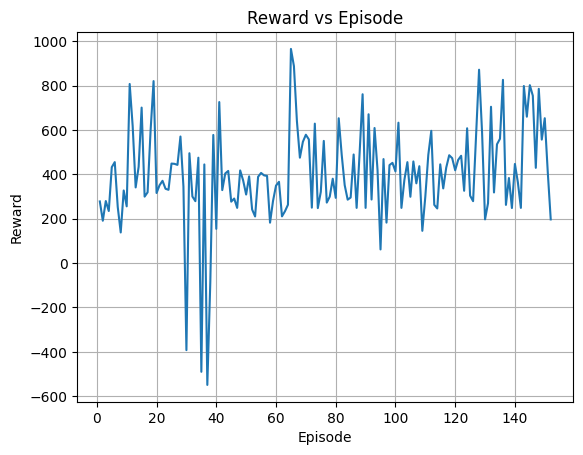

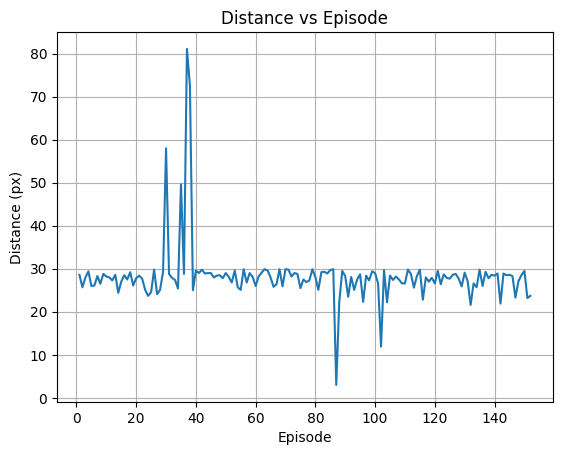

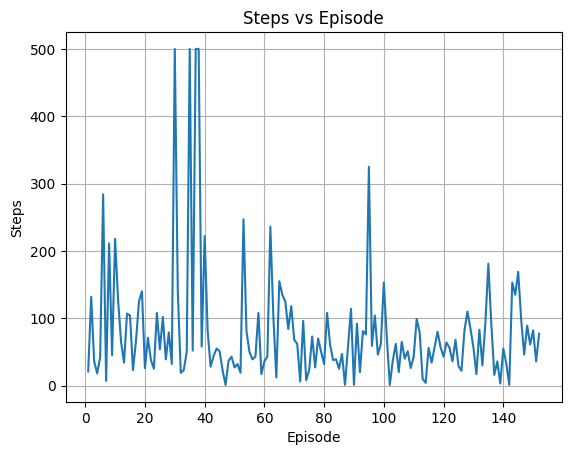

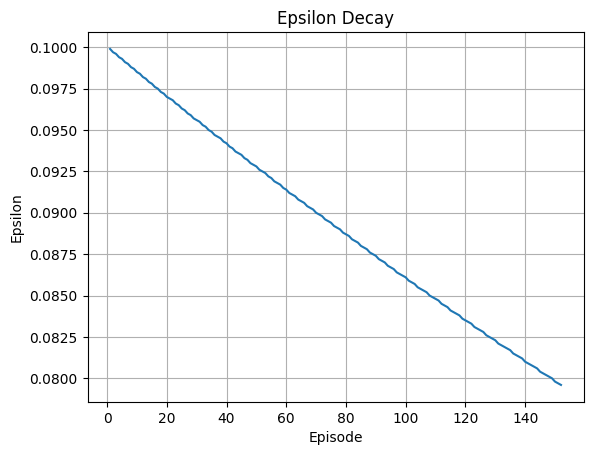

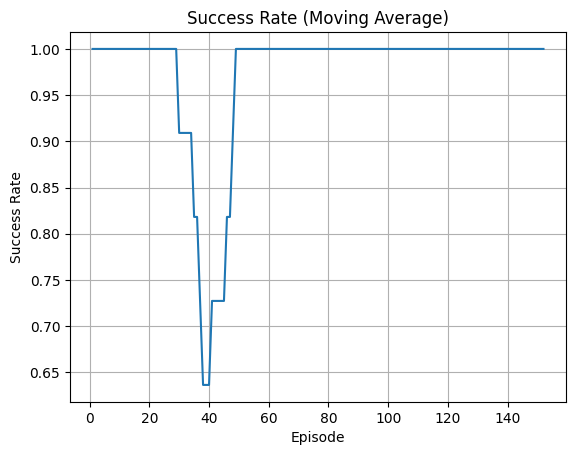

In [8]:
# Lists to store parsed data
episodes = []
rewards = []
distances = []
steps = []
epsilons = []
success = []

# Regex pattern
pattern = re.compile(
    r"Ep\s+(\d+)/\d+\s+(\w+)\s+Reward\s+([+-]?\d+\.\d+)\s+Dist\s+(\d+\.\d+)px\s+Steps\s+(\d+)\s+eps\s+(\d+\.\d+)"
)

# Parse the log
for line in log_data.strip().split("\n"):
    match = pattern.search(line)
    if match:
        ep = int(match.group(1))
        status = match.group(2)
        reward = float(match.group(3))
        dist = float(match.group(4))
        step = int(match.group(5))
        eps = float(match.group(6))

        episodes.append(ep)
        rewards.append(reward)
        distances.append(dist)
        steps.append(step)
        epsilons.append(eps)
        success.append(1 if status == "GOAL" else 0)

# ---- Plotting ---- #

# Reward vs Episode
plt.figure()
plt.plot(episodes, rewards)
plt.title("Reward vs Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid()

# Distance vs Episode
plt.figure()
plt.plot(episodes, distances)
plt.title("Distance vs Episode")
plt.xlabel("Episode")
plt.ylabel("Distance (px)")
plt.grid()

# Steps vs Episode
plt.figure()
plt.plot(episodes, steps)
plt.title("Steps vs Episode")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.grid()

# Epsilon decay
plt.figure()
plt.plot(episodes, epsilons)
plt.title("Epsilon Decay")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid()

# Success rate (moving average)
window = 10
moving_success = [
    sum(success[max(0, i-window):i+1]) / (i - max(0, i-window) + 1)
    for i in range(len(success))
]

plt.figure()
plt.plot(episodes, moving_success)
plt.title("Success Rate (Moving Average)")
plt.xlabel("Episode")
plt.ylabel("Success Rate")
plt.grid()

plt.show()